# 05 — ECS-coloured historical temperature figure

This notebook builds a more complex figure that combines two diagnostics from the REF API:

- the **Equilibrium Climate Sensitivity (ECS)** of each CMIP6 model (a scalar), and
- each model's **global-mean near-surface air temperature timeseries** (a 1-D series).

Every model's historical temperature trajectory is drawn as one line, **coloured by
that model's ECS**. The result shows at a glance how high-sensitivity models warm compared to low-sensitivity ones.

**Prerequisites:** [01 — REF concepts](01-ref-concepts.ipynb), [02 — Querying the REF API](02-querying-the-api.ipynb), [03 — Figure generation](03-publication-figure.ipynb).

## Goal

1. fetch ECS scalar values for every CMIP6 model
2. fetch the historical global-mean `tas` timeseries for those models
3. join them on `source_id`, take the anomaly relative to the 1850-1900 baseline
4. draw one line per model, coloured by ECS, with a multi-model mean overlay
5. save the figure in `.png` and `.pdf` for inclusion in a paper or report.

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from climate_ref_client.api.diagnostics import diagnostics_list_metric_values
from climate_ref_client.models.metric_value_type import MetricValueType
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from ref_tutorials import (
    get_client,
    metric_values_to_dataframe,
    save_figure,
    set_publication_style,
)

client = get_client()
set_publication_style()

## 1. Fetch ECS per model

ECS is published as scalar metric values. Some models have several ensemble members;
we average them to a single value per `source_id`.

In [17]:
ecs_values = diagnostics_list_metric_values.sync(
    provider_slug="esmvaltool",
    diagnostic_slug="equilibrium-climate-sensitivity",
    value_type=MetricValueType.SCALAR,
    client=client,
).data

ecs_df = metric_values_to_dataframe(ecs_values).dropna(subset=["source_id", "value"])
ecs_per_model = ecs_df.groupby("source_id")["value"].mean().rename("ecs").sort_values()
ecs_per_model

source_id
INM-CM4-8          1.829581
INM-CM5-0          1.915838
CAMS-CSM1-0        2.273136
MIROC6             2.607291
MIROC-ES2L         2.675482
GISS-E2-1-G        2.718757
BCC-CSM2-MR        3.041841
BCC-ESM1           3.258833
MRI-ESM2-0         3.355912
CMCC-CM2-SR5       3.520181
CAS-ESM2-0         3.523785
CMCC-ESM2          3.575525
IPSL-CM5A2-INCA    3.800174
ACCESS-ESM1-5      3.839963
E3SM-2-0-NARRM     3.931533
E3SM-2-1           3.934756
E3SM-2-0           3.988133
IPSL-CM6A-LR       4.614185
CESM2-WACCM        4.695278
ACCESS-CM2         4.719077
CNRM-ESM2-1        4.762820
CNRM-CM6-1         4.829452
HadGEM3-GC31-LL    5.546231
CanESM5-1          5.615780
CanESM5            5.623153
Name: ecs, dtype: float64

## 2. Fetch the historical global-mean temperature timeseries

The `global-mean-timeseries` diagnostic publishes a series per
(model, experiment, variable, member). We keep `historical` runs of `tas` and
drop any model that has no matching ECS value.

In [18]:
def fetch_all_series(provider_slug, diagnostic_slug, page_size=500):
    """Fetch every SERIES metric value, paging through `limit`/`offset`."""
    out, offset = [], 0
    while True:
        # This makes multiple API calls as there are more results than `page_size`
        page = diagnostics_list_metric_values.sync(
            provider_slug=provider_slug,
            diagnostic_slug=diagnostic_slug,
            value_type=MetricValueType.SERIES,
            client=client,
            limit=page_size,
            offset=offset,
        ).data
        if not page:
            break
        out.extend(page)
        if len(page) < page_size:
            break
        offset += page_size
    return out


series = fetch_all_series("esmvaltool", "global-mean-timeseries")


def _dim(s, key):
    return s.dimensions.additional_properties.get(key)


historical_tas = [
    s
    for s in series
    if _dim(s, "experiment_id") == "historical"
    and _dim(s, "variable_id") == "tas"
    and _dim(s, "source_id") in ecs_per_model.index
]
print(f"{len(historical_tas)} historical tas series matched to ECS")

29 historical tas series matched to ECS


## 3. Tidy into a wide DataFrame and compute anomalies

Multiple ensemble members per model are averaged year-by-year. 
We then express each model's timeseries as an anomaly relative to its 1850-1900 mean.

In [19]:
long = pd.concat(
    [
        pd.DataFrame(
            {
                "source_id": _dim(s, "source_id"),
                "year": pd.to_datetime(s.index).year,
                "tas": np.asarray(s.values, dtype=float),
            }
        )
        for s in historical_tas
    ],
    ignore_index=True,
)

# Average across ensemble members for each (model, year)
annual = long.groupby(["source_id", "year"], as_index=False)["tas"].mean()
wide = annual.pivot(index="year", columns="source_id", values="tas")

baseline = wide.loc[1850:1900].mean(axis=0)
anom = wide.subtract(baseline, axis=1)
anom = anom.dropna(axis=1, how="all")
anom.tail()

source_id,ACCESS-CM2,ACCESS-ESM1-5,BCC-CSM2-MR,BCC-ESM1,CAMS-CSM1-0,CAS-ESM2-0,CESM2-WACCM,CMCC-CM2-SR5,CMCC-ESM2,CNRM-CM6-1,...,E3SM-2-1,GISS-E2-1-G,HadGEM3-GC31-LL,INM-CM4-8,INM-CM5-0,IPSL-CM5A2-INCA,IPSL-CM6A-LR,MIROC-ES2L,MIROC6,MRI-ESM2-0
year,,,,,,,,,,,,,,,,,,,,,
2010,0.771249,0.887473,0.683188,0.557660,0.602625,0.753495,1.032541,1.243117,1.127415,0.980815,...,0.318849,0.852303,1.049100,1.017280,0.818475,1.443304,1.515814,0.730628,0.580673,0.694784
2011,0.892403,0.936118,0.761740,0.584668,0.672419,0.953965,1.247721,1.337691,1.278325,0.872356,...,0.479463,0.768227,1.211271,0.953895,0.782861,1.453985,1.139471,0.790213,0.568710,0.732870
2012,1.028085,0.950980,0.806876,0.526196,0.762644,0.904893,1.268412,1.467452,1.372776,1.127727,...,0.459047,0.535317,1.124387,0.953437,0.824213,1.625005,1.384344,0.876578,0.687118,0.860983
2013,0.744515,1.055289,0.863181,0.552594,0.863550,0.885789,1.112772,1.417891,1.210942,1.006419,...,0.395265,0.806313,1.113187,1.024940,0.857080,1.749944,1.355688,0.782538,1.041763,0.902548
2014,0.963937,1.040672,0.914511,0.673657,0.737406,0.935197,1.155527,1.342543,1.128270,0.919475,...,0.517244,1.004433,1.232572,0.951942,0.871912,1.516912,1.230475,0.771598,0.920639,0.903799


## 4. Build the figure

Each line is one model, coloured by its ECS using a sequential colormap. The
multi-model mean is overlaid in black, the IPCC AR6 *very likely* ECS range (2.0-5.0 °C)
is marked on the colourbar, and the figure uses the publication style applied above.

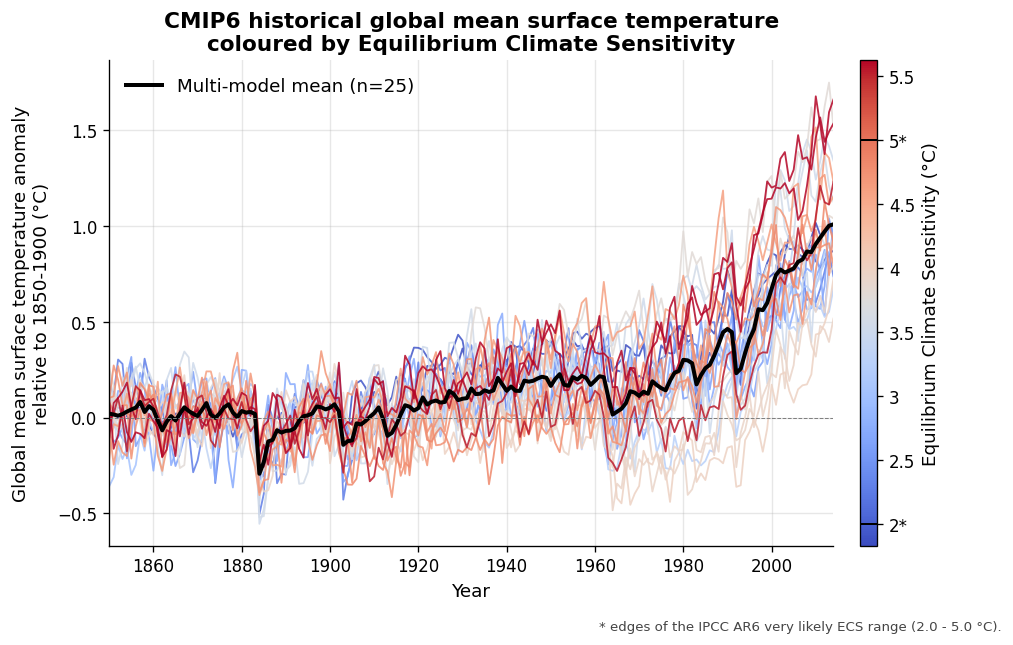

In [20]:
models = [m for m in ecs_per_model.index if m in anom.columns]
ecs_vals = ecs_per_model.loc[models].to_numpy()

norm = Normalize(vmin=float(ecs_vals.min()), vmax=float(ecs_vals.max()))
cmap = plt.get_cmap("coolwarm")

fig, ax = plt.subplots(figsize=(8.5, 5.4))

for model in models:
    s = anom[model].dropna()
    ax.plot(
        s.index,
        s.values,
        color=cmap(norm(ecs_per_model[model])),
        linewidth=1.1,
        alpha=0.85,
    )

mm_mean = anom[models].mean(axis=1)
ax.plot(
    mm_mean.index,
    mm_mean.values,
    color="black",
    linewidth=2.4,
    label=f"Multi-model mean (n={len(models)})",
)

ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
ax.set_xlim(1850, int(mm_mean.index.max()))
ax.margins(x=0)
ax.set_xlabel("Year")
ax.set_ylabel("Global mean surface temperature anomaly\nrelative to 1850-1900 (°C)")
ax.set_title("CMIP6 historical global mean surface temperature\ncoloured by Equilibrium Climate Sensitivity")
ax.legend(loc="upper left")

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.03, aspect=28)
cbar.set_label("Equilibrium Climate Sensitivity (°C)")

# Mark the IPCC AR6 very likely ECS range (2.0-5.0 °C) directly on the colourbar.
very_likely_lo, very_likely_hi = 2.0, 5.0
for level in (very_likely_lo, very_likely_hi):
    if norm.vmin <= level <= norm.vmax:
        cbar.ax.axhline(level, color="black", linewidth=1.2)

# Re-label the colourbar ticks so the AR6 very-likely range edges are explicit.
ticks = sorted({round(t, 2) for t in cbar.get_ticks()} | {very_likely_lo, very_likely_hi})
ticks = [t for t in ticks if norm.vmin <= t <= norm.vmax]
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:g}*" if t in (very_likely_lo, very_likely_hi) else f"{t:g}" for t in ticks])

fig.text(
    0.99,
    0.01,
    "* edges of the IPCC AR6 very likely ECS range (2.0 - 5.0 °C).",
    ha="right",
    va="bottom",
    fontsize=8,
    color="#444444",
)

fig.tight_layout(rect=(0, 0.03, 1, 1))

## 5. Save the figure

`save_figure` writes both a 300 dpi `.png` (for quick viewing) and a `.pdf`
(vector, for papers).

In [21]:
save_figure(fig, "output/ecs-temperature-timeseries")

[PosixPath('output/ecs-temperature-timeseries.png'),
 PosixPath('output/ecs-temperature-timeseries.pdf')]

## 6. Alternative views of the same relationship

The spaghetti plot above shows the *trajectory* of each model. 
Two complementary panels make the ECS -> warming link even more direct:

- a **model-by-model heatmap** with rows sorted by ECS (IPCC "warming-stripes" style), and
- a **scatter** of end-of-historical warming against ECS with a linear fit.

[PosixPath('output/ecs-warming-stripes.png'),
 PosixPath('output/ecs-warming-stripes.pdf')]

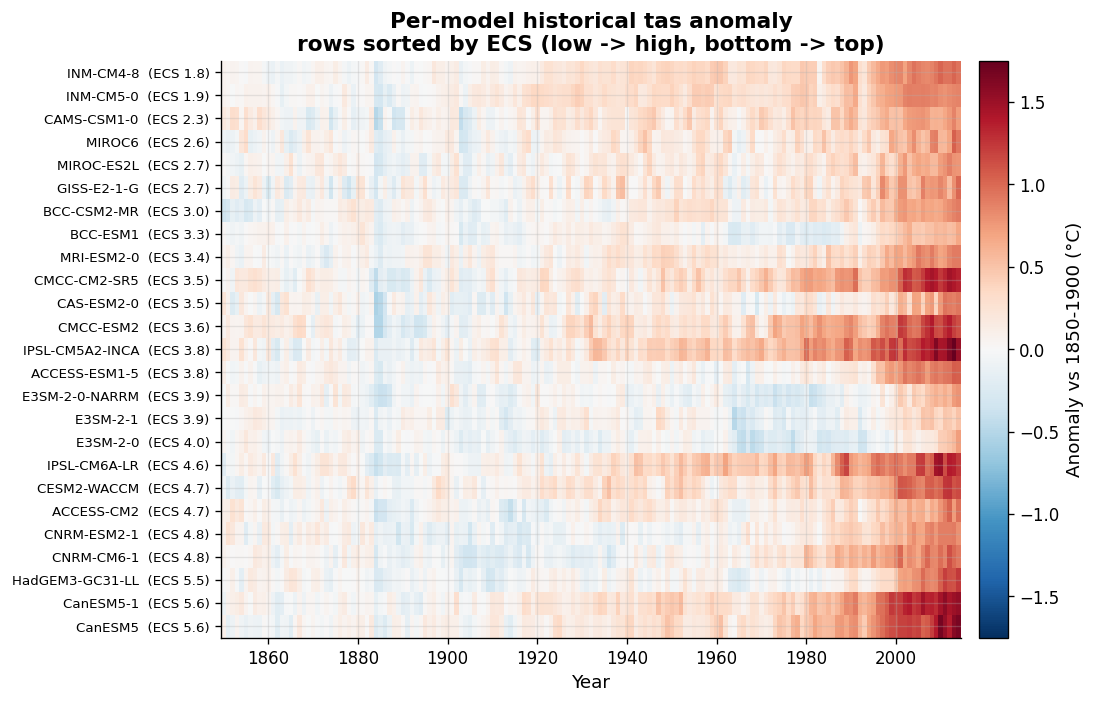

In [22]:
order = ecs_per_model.loc[models].sort_values().index.tolist()
mat = anom[order].T  # rows = model (sorted by ECS), cols = year

vmax = float(np.nanmax(np.abs(mat.values)))

fig_h, ax_h = plt.subplots(figsize=(9.5, 6.0))
mesh = ax_h.pcolormesh(
    mat.columns.values,
    np.arange(len(order)),
    mat.values,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    shading="auto",
)
ax_h.set_yticks(np.arange(len(order)))
ax_h.set_yticklabels([f"{m}  (ECS {ecs_per_model[m]:.1f})" for m in order], fontsize=8)
ax_h.set_xlabel("Year")
ax_h.set_title("Per-model historical tas anomaly\nrows sorted by ECS (low -> high, bottom -> top)")
ax_h.invert_yaxis()  # lowest ECS at the top reads naturally with the colourbar

cbar_h = fig_h.colorbar(mesh, ax=ax_h, pad=0.02)
cbar_h.set_label("Anomaly vs 1850-1900 (°C)")

fig_h.tight_layout()
save_figure(fig_h, "output/ecs-warming-stripes")

### Scatter: end-of-historical warming vs ECS

For each model we take the mean anomaly over the last 20 years of the historical run (1995-2014) and plot it against the model's ECS. 
A linear least-squares fit quantifies how strongly recent simulated warming tracks sensitivity.

[PosixPath('output/ecs-vs-warming-scatter.png'),
 PosixPath('output/ecs-vs-warming-scatter.pdf')]

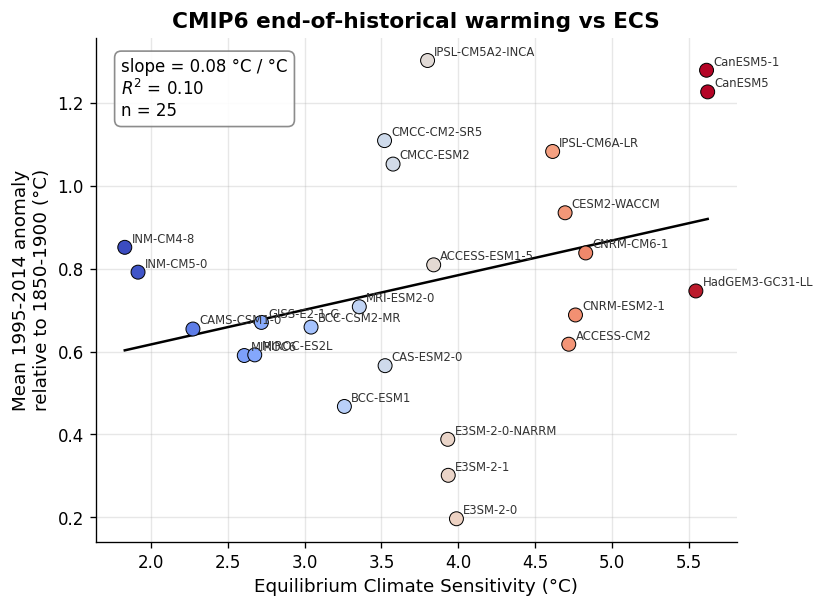

In [23]:
late = anom.loc[1995:2014, models].mean(axis=0)
ecs_x = ecs_per_model.loc[models]

slope, intercept = np.polyfit(ecs_x.values, late.values, 1)
r = np.corrcoef(ecs_x.values, late.values)[0, 1]

fig_s, ax_s = plt.subplots(figsize=(7.0, 5.2))
ax_s.scatter(
    ecs_x,
    late,
    c=ecs_x,
    cmap=cmap,
    norm=norm,
    s=70,
    edgecolor="black",
    linewidth=0.6,
    zorder=3,
)

xfit = np.linspace(ecs_x.min(), ecs_x.max(), 50)
ax_s.plot(xfit, slope * xfit + intercept, color="black", linewidth=1.5, zorder=2)

ax_s.text(
    0.04,
    0.96,
    f"slope = {slope:.2f} °C / °C\n$R^2$ = {r**2:.2f}\nn = {len(models)}",
    transform=ax_s.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="grey", alpha=0.9),
)

for m in models:
    ax_s.annotate(
        m,
        (ecs_x[m], late[m]),
        fontsize=7,
        xytext=(4, 3),
        textcoords="offset points",
        color="#333333",
    )

ax_s.set_xlabel("Equilibrium Climate Sensitivity (°C)")
ax_s.set_ylabel("Mean 1995-2014 anomaly\nrelative to 1850-1900 (°C)")
ax_s.set_title("CMIP6 end-of-historical warming vs ECS")

fig_s.tight_layout()
save_figure(fig_s, "output/ecs-vs-warming-scatter")

Swap `experiment_id` to `"ssp585"` (or any other) to draw the same figure for a future scenario, or change the colormap and baseline to suit a different report.